1. Import Library

In [26]:
import pandas as pd
import numpy as np
import re
import pickle
import mlflow

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from preprocess import Preprocessor
from train import Trainer
from evaluate import Evaluator

2. Load Dataset

In [27]:
df = pd.read_csv("data_C.csv")

3. Cek Data

In [28]:
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,...,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897591535379,High_spent_Small_value_payments,303.917665,Standard
1,1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.571667,...,Standard,2149.9,23.451285,NaN,Yes,11.564437,54.46174813453877,Low_spent_Medium_value_payments,309.130981,Poor
2,2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.070000,...,Good,387.53,31.100297,24 Years and 3 Months,No,98.031931,478.3574716999517,High_spent_Small_value_payments,920.817597,Standard
3,3,0x8ac9,CUS_0x5534,April,Aubinr,39,246-34-3138,Developer,23200.82,NaN,...,Standard,987.07,26.786925,17 Years and 7 Months,Yes,0.000000,65.84983488267585,Low_spent_Large_value_payments,391.890332,Standard
4,4,0x24a41,CUS_0x104f,April,Markm,20,264-84-8069,Architect,11336.835,992.736250,...,Standard,177.98,24.001752,14 Years and 7 Months,Yes,35.562731,NaN,Low_spent_Small_value_payments,228.245999,Standard


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22570 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21164 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [30]:
df.isnull().sum()

Unnamed: 0                     0
ID                             0
Customer_ID                    0
Month                          0
Name                        2430
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       3836
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                2852
Delay_from_due_date            0
Num_of_Delayed_Payment      1792
Changed_Credit_Limit           0
Num_Credit_Inquiries         472
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          2240
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     1134
Payment_Behaviour              0
Monthly_Balance              301
Credit_Score                   0
dtype: int64

4. Hapus Kolom yang Tidak Digunakan

In [31]:
drop_cols = [
    "Unnamed: 0",
    "ID",
    "Customer_ID",
    "Name",
    "SSN"
]

df = df.drop(columns=drop_cols, errors="ignore")

In [32]:
df = df.drop(columns=["Type_of_Loan"])

5. Bersihkan Kolom Numerik

In [33]:
numeric_cols = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly"
]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("_", "", regex=False)
    )

    df[col] = pd.to_numeric(df[col], errors="coerce")

6. Ubah Credit History Age Menjadi Bulan

In [34]:
def convert_history(x):

    if pd.isna(x):
        return np.nan

    match = re.search(r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?', str(x))

    if match:
        years = int(match.group(1))
        months = int(match.group(2))
        return years * 12 + months

    return np.nan

df["Credit_History_Age"] = df["Credit_History_Age"].apply(convert_history)

7. Isi Missing Value

In [35]:
for col in df.columns:

    if df[col].dtype == "object":

        mode = df[col].mode()

        if len(mode) > 0:
            df[col] = df[col].fillna(mode[0])

    else:

        df[col] = df[col].fillna(df[col].median())

8. Encode Kolom Kategori

Kolom yang di-encode: Month, Occupation, Credit_Mix, Payment_of_Min_Amount, Payment_Behaviour.
Kolom Type_of_Loan tidak di-encode karena berisi multiple nilai per baris (contoh: "Personal Loan, Student Loan")
dan tidak digunakan sebagai fitur model.

In [36]:
# kolom yang perlu di-encode (Type_of_Loan tidak dipakai karena multi-value)
cat_cols = [
    "Month",
    "Occupation",
    "Credit_Mix",
    "Payment_of_Min_Amount",
    "Payment_Behaviour"
]

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

9. Encode Target

In [37]:
target_encoder = LabelEncoder()

df["Credit_Score"] = target_encoder.fit_transform(df["Credit_Score"])

In [38]:
print(target_encoder.classes_)

['Good' 'Poor' 'Standard']


10. Cek Data Setelah Preprocessing

Total kolom sekarang 23 (turun dari 24), karena Type_of_Loan tidak diikutsertakan.
Semua kolom sudah tidak ada missing value.

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  int64  
 1   Age                       25000 non-null  int64  
 2   Occupation                25000 non-null  int64  
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     25000 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  int64  
 9   Delay_from_due_date       25000 non-null  int64  
 10  Num_of_Delayed_Payment    25000 non-null  float64
 11  Changed_Credit_Limit      25000 non-null  float64
 12  Num_Credit_Inquiries      25000 non-null  float64
 13  Credit_Mix                25000 non-null  int64  
 14  Outsta

11. Split Data

In [40]:
X = df.drop("Credit_Score", axis=1)

y = df["Credit_Score"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

12. Training Model dengan MLflow

Menggunakan class Trainer dari train.py yang mencoba 3 model:
- Random Forest
- Gradient Boosting
- Decision Tree

Semua hasil eksperimen dicatat ke MLflow. Model terbaik (accuracy tertinggi) disimpan otomatis
sebagai credit_model.pkl.

Untuk melihat hasil eksperimen: jalankan `mlflow ui` di terminal, lalu buka http://localhost:5000

In [42]:
# Gunakan class Trainer dari train.py
# Trainer akan mencoba 3 model dan mencatat semua ke MLflow
trainer = Trainer()
best_model = trainer.train(X_train, y_train, X_test, y_test)

2026/06/29 23:21:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/29 23:21:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[RandomForest] Accuracy: 0.7354


2026/06/29 23:22:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/29 23:22:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[GradientBoosting] Accuracy: 0.6982


2026/06/29 23:22:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/29 23:22:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[DecisionTree] Accuracy: 0.6296

Model terbaik: RandomForest dengan accuracy 0.7354


13. Perbandingan Hasil Model

Model terbaik dipilih secara otomatis berdasarkan accuracy tertinggi oleh class Trainer.
Semua hasil eksperimen (accuracy, f1-score) sudah tercatat di MLflow.
Jalankan `mlflow ui` untuk melihat perbandingan detail.

In [43]:
# Bandingkan hasil dari MLflow
# (Tabel perbandingan sudah otomatis tersimpan di MLflow)
# Di sini kita tampilkan ulang dari variabel yang ada di Trainer

results = pd.DataFrame({
    "Model": ["RandomForest", "GradientBoosting", "DecisionTree"],
    "Note": [
        "Model terbaik dipilih otomatis oleh Trainer",
        "Dicatat di MLflow",
        "Dicatat di MLflow"
    ]
})

results

,Model,Note
0,RandomForest,Model terbaik dipilih otomatis oleh Trainer
1,GradientBoosting,Dicatat di MLflow
2,DecisionTree,Dicatat di MLflow


14. Evaluasi Model Terbaik

Menggunakan class Evaluator dari evaluate.py untuk menampilkan
accuracy dan classification report dari model terbaik.

In [44]:
from importlib import reload
import evaluate

reload(evaluate)

from evaluate import Evaluator

In [45]:
import evaluate
print(evaluate.__file__)

c:\Users\LENOVO\Documents\KULYEAH\MODEL DEPLOYMENT\AOL\evaluate.py


In [49]:
# Evaluasi model terbaik menggunakan class Evaluator dari evaluate.py
evaluator = Evaluator()
acc, report = evaluator.evaluate(best_model, X_test, y_test)

Accuracy : 0.7354
              precision    recall  f1-score   support

           0       0.63      0.67      0.65       890
           1       0.74      0.72      0.73      1454
           2       0.77      0.77      0.77      2656

    accuracy                           0.74      5000
   macro avg       0.71      0.72      0.72      5000
weighted avg       0.74      0.74      0.74      5000



15. Classification Report

In [50]:
print(classification_report(y_test, pred_rf))

NameError: name 'pred_rf' is not defined

16. Confusion Matrix

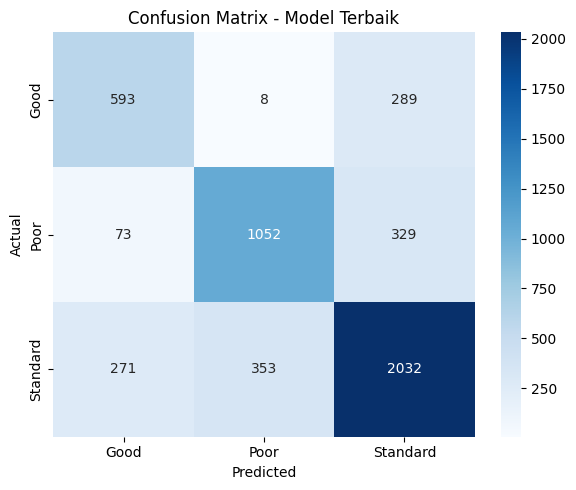

In [ ]:
pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title("Confusion Matrix - Model Terbaik")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

17. Simpan Model Terbaik


Model terbaik dipilih otomatis oleh class Trainer berdasarkan accuracy tertinggi.
Encoder fitur dan encoder target disimpan untuk digunakan saat inferencing.

In [ ]:
# Model sudah otomatis disimpan sebagai credit_model.pkl oleh Trainer
# Simpan encoder dan target encoder
pickle.dump(encoders, open("encoders.pkl", "wb"))
pickle.dump(target_encoder, open("target_encoder.pkl", "wb"))

print("Semua file berhasil disimpan:")
print("- credit_model.pkl (model terbaik)")
print("- encoders.pkl (encoder fitur kategorikal)")
print("- target_encoder.pkl (encoder label Credit_Score)")

Semua file berhasil disimpan:
- credit_model.pkl (model terbaik)
- encoders.pkl (encoder fitur kategorikal)
- target_encoder.pkl (encoder label Credit_Score)
